In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
start = pd.read_csv("./data/batch_times.csv")
start.loc[10, "Start Date"] = "09/02/2026"
start["Start Date"] = pd.to_datetime(start["Start Date"], dayfirst = True)
start["End Date"] = pd.to_datetime(start["End Date"], dayfirst = True)
start.insert(1, "db", ["DB440"] * 4 + ["DB450"] * 4 + ["DB460"] * 3)
start = start.sort_values(by = "Batch").reset_index(drop = True)
start.loc[1, "Start Date"] = pd.to_datetime("2025-04-19")
start

,Batch,db,Start Date,End Date
0,FA001,DB450,2025-04-01,2025-04-16
1,FA002,DB450,2025-04-19,2025-05-14
2,FA003,DB450,2025-05-20,2025-06-04
3,FA004,DB440,2025-11-17,2025-12-03
4,FA005,DB450,2025-12-01,2025-12-16
5,FA006,DB460,2025-12-23,2026-01-07
6,FA007,DB440,2026-01-06,2026-01-21
7,FA008,DB460,2026-01-20,2026-02-04
8,FA009,DB440,2026-01-30,2026-02-14
9,FA010,DB460,2026-02-09,2026-02-24


In [3]:
start_copy = start[["Start Date", "Batch"]]
start_copy.columns = ["start", "batch"]

In [4]:
df = pd.read_excel("./data/WI870.xlsx")
print(df.shape)
df["start"] = pd.to_datetime(df["start"])
df["end"] = pd.to_datetime(df["end"])
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = pd.merge(start_copy, df)

df = df[(df["start"] != "2025-04-19") | (df["timestamp"] >= pd.to_datetime("2025-04-29"))].reset_index(drop = True)

print(df.shape)
df["start"] = df["start"].apply(lambda x: x if x != pd.to_datetime("2025-04-19") else pd.to_datetime("2025-04-29"))
df = df.reset_index(drop = True)
df

(41579, 7)
(41141, 8)


,start,batch,db,end,tag,point,timestamp,value
0,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,2025-04-01 00:00:00.000000000,0.587767
1,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,2025-04-01 01:45:48.771133400,0.588000
2,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,2025-04-01 07:05:44.935302700,0.588000
3,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,2025-04-01 07:05:47.943023600,0.574000
4,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,2025-04-01 07:06:03.997619600,0.582000
...,...,...,...,...,...,...,...,...
41136,2026-02-19,FA011,DB0440,2026-03-06 23:59:59,WI870_value,DB0440_WI870_value,2026-03-06 14:49:43.853866500,0.009000
41137,2026-02-19,FA011,DB0440,2026-03-06 23:59:59,WI870_value,DB0440_WI870_value,2026-03-06 14:49:44.859954800,0.000000
41138,2026-02-19,FA011,DB0440,2026-03-06 23:59:59,WI870_value,DB0440_WI870_value,2026-03-06 14:51:21.115951500,0.000000
41139,2026-02-19,FA011,DB0440,2026-03-06 23:59:59,WI870_value,DB0440_WI870_value,2026-03-06 14:51:23.112640300,-0.012000


In [5]:
df.insert(6, "day since start", (df["timestamp"] - df["start"]).dt.days.tolist())

In [6]:
df

,start,batch,db,end,tag,point,day since start,timestamp,value
0,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 00:00:00.000000000,0.587767
1,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 01:45:48.771133400,0.588000
2,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:05:44.935302700,0.588000
3,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:05:47.943023600,0.574000
4,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:06:03.997619600,0.582000
...,...,...,...,...,...,...,...,...,...
41136,2026-02-19,FA011,DB0440,2026-03-06 23:59:59,WI870_value,DB0440_WI870_value,15,2026-03-06 14:49:43.853866500,0.009000
41137,2026-02-19,FA011,DB0440,2026-03-06 23:59:59,WI870_value,DB0440_WI870_value,15,2026-03-06 14:49:44.859954800,0.000000
41138,2026-02-19,FA011,DB0440,2026-03-06 23:59:59,WI870_value,DB0440_WI870_value,15,2026-03-06 14:51:21.115951500,0.000000
41139,2026-02-19,FA011,DB0440,2026-03-06 23:59:59,WI870_value,DB0440_WI870_value,15,2026-03-06 14:51:23.112640300,-0.012000


In [7]:
agg_df = df[["batch", "day since start", "value"]].groupby(["batch", "day since start"]).sum().reset_index()
agg_df

,batch,day since start,value
0,FA001,0,27.139768
1,FA001,1,133.416001
2,FA001,2,469.153000
3,FA001,3,31.009000
4,FA001,4,17.657000
...,...,...,...
172,FA011,11,101.204000
173,FA011,12,86.793000
174,FA011,13,58.201000
175,FA011,14,61.475000


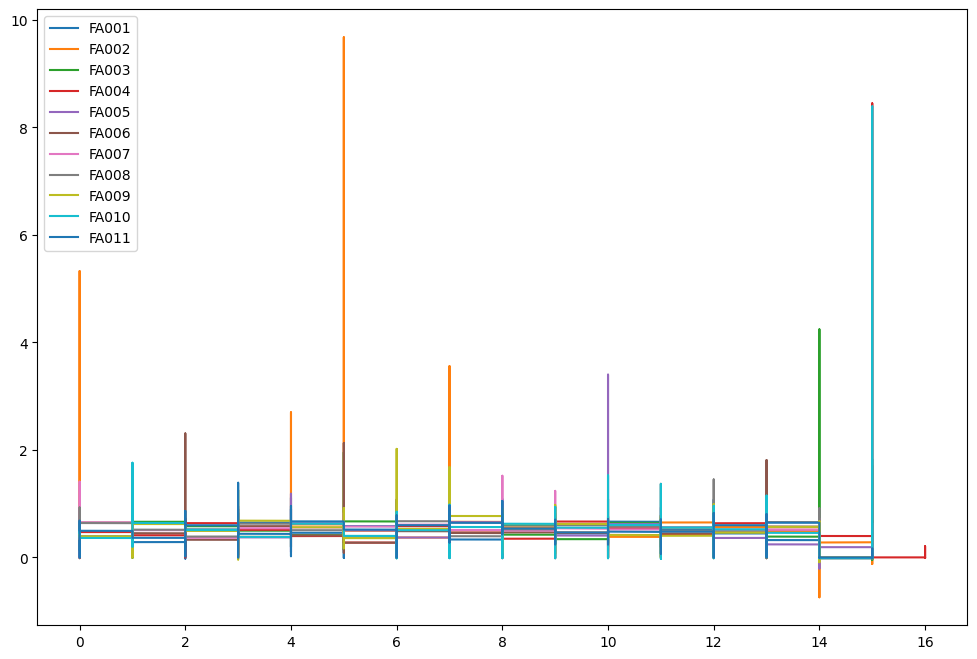

In [8]:
plt.figure(figsize = (12, 8))

for batch in agg_df["batch"].unique():
    sub_df = df[df["batch"] == batch].copy()
    # sub_df = sub_df[sub_df["value"] > 0.75]
    plt.plot(sub_df["day since start"], sub_df["value"], label = batch)
# plt.hlines(0.75, 0, 16, linestyle = '--')
plt.legend()
plt.show()

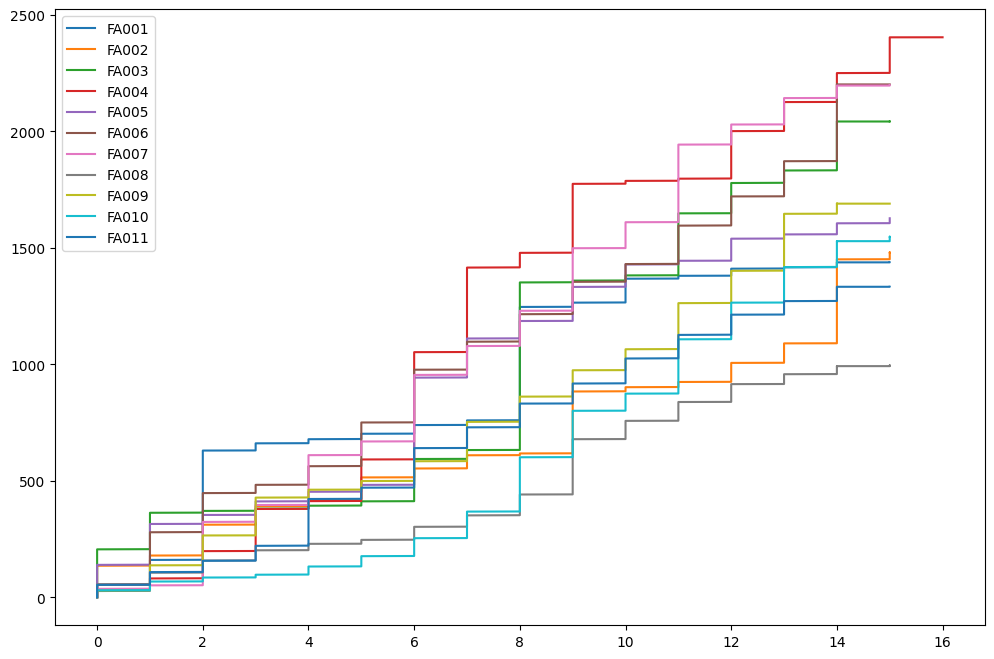

In [9]:
plt.figure(figsize = (12, 8))

for batch in agg_df["batch"].unique():
    sub_df = df[df["batch"] == batch].copy()
    # sub_df = sub_df[sub_df["value"] > 0.75]
    plt.plot(sub_df["day since start"], sub_df["value"].cumsum(), label = batch)
# plt.hlines(0.75, 0, 16, linestyle = '--')
plt.legend()
plt.show()

In [10]:
df.head(10)

,start,batch,db,end,tag,point,day since start,timestamp,value
0,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 00:00:00.000000000,0.587767
1,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 01:45:48.771133400,0.588000
2,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:05:44.935302700,0.588000
3,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:05:47.943023600,0.574000
4,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:06:03.997619600,0.582000
5,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:06:20.029190000,0.587000
6,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:08:32.527725200,0.589000
7,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 08:14:27.573944000,0.591000
8,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 09:57:49.115615800,0.592000
9,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 10:51:54.301177900,0.593000


In [11]:
qwe = pd.pivot_table(agg_df, "value", "batch", "day since start").reset_index().values
qwe = pd.DataFrame(qwe, columns = ["Batch"] + [f"Day {i}" for i in range(17)])
qwe.insert(1, "True Total Antifoam", [2.462, 1.569, 1.380, 1.754, 1.780, 3.484, 4.396, 3.36, 3.63, 4.292, 3.876])
qwe

,Batch,True Total Antifoam,Day 0,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7,Day 8,Day 9,Day 10,Day 11,Day 12,Day 13,Day 14,Day 15,Day 16
0,FA001,2.462,27.139768,133.416001,469.153,31.009,17.657,23.39,37.323,20.017,486.707997,18.361,102.749001,12.446,30.547,5.733,21.411,0.017,NaN
1,FA002,1.569,135.635001,43.690001,132.271,79.255001,26.495,97.116,38.317,56.662,7.885,265.770997,18.433,22.413,81.796,83.748,360.462999,30.146,NaN
2,FA003,1.380,205.916408,156.874001,8.04,9.685,12.579,18.772,181.661999,38.382,719.023015,7.766,22.342,266.248002,130.164,53.683999,210.197002,0.847,NaN
3,FA004,1.754,54.837639,26.208,117.231001,180.812002,33.635,178.763997,460.372002,362.792997,63.175998,296.021998,12.719,9.44,204.069001,124.609,124.336,153.371002,0.216
4,FA005,1.780,139.330229,175.412998,38.729,58.027001,41.429,29.605,459.995002,167.936998,75.021,146.202,96.312,15.821,94.784997,18.313,47.704,21.557,NaN
5,FA006,3.484,53.691,225.531998,168.040994,35.398,79.915999,187.568002,226.390001,120.055999,118.028,138.828,76.311999,164.824999,125.320002,151.090998,329.353989,-0.038,NaN
6,FA007,4.396,36.426,15.035,272.045004,72.510002,213.968,58.684,285.480998,123.991,151.187999,268.386001,111.546,332.965999,86.159002,113.389,53.689,1.286,NaN
7,FA008,3.360,55.507001,50.214,52.114,43.99,27.729,16.979,55.991,49.07,89.614,237.253,78.632,80.912,76.681,42.553,34.691,3.229,NaN
8,FA009,3.630,29.1,108.220998,128.166,162.362997,33.851,37.208,85.012,168.821001,108.297,113.149,90.117,197.776,138.618002,244.602,43.618,0.0,NaN
9,FA010,4.292,30.406,37.386,17.218,12.08,35.176,44.374,77.168,114.053999,233.085999,199.291,73.637,233.072001,157.229,152.481001,111.388998,19.153,NaN


In [12]:
qwe[qwe.columns[1:]].sum(axis = 1)

0     1439.538767
1        1481.665
2     2043.561425
3     2404.364637
4     1627.960225
5     2203.795979
6     2201.145004
7      998.519001
8     1692.548996
9     1551.491997
10    1336.328993
dtype: object

In [13]:
last_df = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", header = 1)
last_df = last_df[2:].reset_index(drop = True)
last_df.columns = ["Batch", "Batch Full Name"] + last_df.columns[2:].tolist()

target_var = "STR2K_D14_4_1_PA_HPLC_Concentration"
label = last_df[["Batch", target_var]].copy()
label.columns = ["Batch", "Last Titer"]
label

,Batch,Last Titer
0,FA001,5.19
1,FA002,4.86
2,FA003,4.63
3,FA004,4.62
4,FA005,3.91
5,FA006,5.63
6,FA007,5.79
7,FA008,5.89
8,FA009,4.84
9,FA010,5.56


In [14]:
df.head(10)

,start,batch,db,end,tag,point,day since start,timestamp,value
0,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 00:00:00.000000000,0.587767
1,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 01:45:48.771133400,0.588000
2,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:05:44.935302700,0.588000
3,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:05:47.943023600,0.574000
4,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:06:03.997619600,0.582000
5,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:06:20.029190000,0.587000
6,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 07:08:32.527725200,0.589000
7,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 08:14:27.573944000,0.591000
8,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 09:57:49.115615800,0.592000
9,2025-04-01,FA001,DB0450,2025-04-16 23:59:59,WI870_value,DB0450_WI870_value,0,2025-04-01 10:51:54.301177900,0.593000


In [15]:
antifoam_df = pd.merge(qwe, label, on = "Batch")
antifoam_df

,Batch,True Total Antifoam,Day 0,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7,Day 8,Day 9,Day 10,Day 11,Day 12,Day 13,Day 14,Day 15,Day 16,Last Titer
0,FA001,2.462,27.139768,133.416001,469.153,31.009,17.657,23.39,37.323,20.017,486.707997,18.361,102.749001,12.446,30.547,5.733,21.411,0.017,NaN,5.19
1,FA002,1.569,135.635001,43.690001,132.271,79.255001,26.495,97.116,38.317,56.662,7.885,265.770997,18.433,22.413,81.796,83.748,360.462999,30.146,NaN,4.86
2,FA003,1.380,205.916408,156.874001,8.04,9.685,12.579,18.772,181.661999,38.382,719.023015,7.766,22.342,266.248002,130.164,53.683999,210.197002,0.847,NaN,4.63
3,FA004,1.754,54.837639,26.208,117.231001,180.812002,33.635,178.763997,460.372002,362.792997,63.175998,296.021998,12.719,9.44,204.069001,124.609,124.336,153.371002,0.216,4.62
4,FA005,1.780,139.330229,175.412998,38.729,58.027001,41.429,29.605,459.995002,167.936998,75.021,146.202,96.312,15.821,94.784997,18.313,47.704,21.557,NaN,3.91
5,FA006,3.484,53.691,225.531998,168.040994,35.398,79.915999,187.568002,226.390001,120.055999,118.028,138.828,76.311999,164.824999,125.320002,151.090998,329.353989,-0.038,NaN,5.63
6,FA007,4.396,36.426,15.035,272.045004,72.510002,213.968,58.684,285.480998,123.991,151.187999,268.386001,111.546,332.965999,86.159002,113.389,53.689,1.286,NaN,5.79
7,FA008,3.360,55.507001,50.214,52.114,43.99,27.729,16.979,55.991,49.07,89.614,237.253,78.632,80.912,76.681,42.553,34.691,3.229,NaN,5.89
8,FA009,3.630,29.1,108.220998,128.166,162.362997,33.851,37.208,85.012,168.821001,108.297,113.149,90.117,197.776,138.618002,244.602,43.618,0.0,NaN,4.84
9,FA010,4.292,30.406,37.386,17.218,12.08,35.176,44.374,77.168,114.053999,233.085999,199.291,73.637,233.072001,157.229,152.481001,111.388998,19.153,NaN,5.56


In [18]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def fit_summary(X, y):
    """
    Fit a linear regression model and return:
      - min X
      - predicted y at min X
      - max X
      - predicted y at max X
      - R² score
    """
    
    X = np.asarray(X).reshape(-1, 1)
    y = np.asarray(y)

    # Fit model
    model = LinearRegression()
    model.fit(X, y)

    # Min and max X values
    x_min = float(X.min())
    x_max = float(X.max())

    # Predicted y values at min/max X
    y_min_fit = float(model.predict([[x_min]])[0])
    y_max_fit = float(model.predict([[x_max]])[0])

    # R²
    y_pred = model.predict(X)
    r2 = float(r2_score(y, y_pred))

    return {
        "x_min": x_min,
        "y_fit_at_x_min": y_min_fit,
        "x_max": x_max,
        "y_fit_at_x_max": y_max_fit,
        "r2": r2,
        "slope": float(model.coef_[0]),
        "intercept": float(model.intercept_)
    }

In [30]:
antifoam_cum_df = antifoam_df.copy().T

antifoam_cum_df[2:-1] = antifoam_cum_df[2:-1].cumsum()
antifoam_cum_df = antifoam_cum_df.T
antifoam_cum_df

,Batch,True Total Antifoam,Day 0,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7,Day 8,Day 9,Day 10,Day 11,Day 12,Day 13,Day 14,Day 15,Day 16,Last Titer
0,FA001,2.462,27.139768,160.555769,629.708769,660.717769,678.374768,701.764768,739.087768,759.104768,1245.812765,1264.173766,1366.922767,1379.368767,1409.915767,1415.648767,1437.059767,1437.076767,NaN,5.19
1,FA002,1.569,135.635001,179.325002,311.596002,390.851003,417.346003,514.462003,552.779003,609.441003,617.326003,883.097,901.53,923.943,1005.739001,1089.487001,1449.95,1480.096,NaN,4.86
2,FA003,1.38,205.916408,362.790409,370.830409,380.515409,393.094409,411.866409,593.528408,631.910408,1350.933422,1358.699422,1381.041422,1647.289424,1777.453424,1831.137423,2041.334425,2042.181425,NaN,4.63
3,FA004,1.754,54.837639,81.045639,198.27664,379.088642,412.723642,591.487639,1051.859641,1414.652638,1477.828636,1773.850634,1786.569634,1796.009634,2000.078635,2124.687635,2249.023635,2402.394637,2402.610637,4.62
4,FA005,1.78,139.330229,314.743227,353.472227,411.499228,452.928228,482.533228,942.52823,1110.465228,1185.486228,1331.688228,1428.000227,1443.821228,1538.606225,1556.919225,1604.623225,1626.180225,NaN,3.91
5,FA006,3.484,53.691,279.222998,447.263991,482.661991,562.57799,750.145992,976.535993,1096.591993,1214.619993,1353.447993,1429.759991,1594.58499,1719.904992,1870.99599,2200.349979,2200.311979,NaN,5.63
6,FA007,4.396,36.426,51.461,323.506004,396.016006,609.984006,668.668006,954.149004,1078.140003,1229.328003,1497.714003,1609.260003,1942.226003,2028.385005,2141.774005,2195.463004,2196.749004,NaN,5.79
7,FA008,3.36,55.507001,105.721001,157.835001,201.825002,229.554002,246.533002,302.524001,351.594001,441.208001,678.461001,757.093001,838.005001,914.686001,957.239001,991.930001,995.159001,NaN,5.89
8,FA009,3.63,29.1,137.320997,265.486997,427.849994,461.700994,498.908994,583.920994,752.741995,861.038995,974.187995,1064.304995,1262.080994,1400.698996,1645.300996,1688.918996,1688.918996,NaN,4.84
9,FA010,4.292,30.406,67.792,85.01,97.09,132.266,176.64,253.808,367.861999,600.947998,800.238998,873.875998,1106.947998,1264.176998,1416.657999,1528.046997,1547.199997,NaN,5.56


/tmp/ipykernel_2304150/2077863674.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


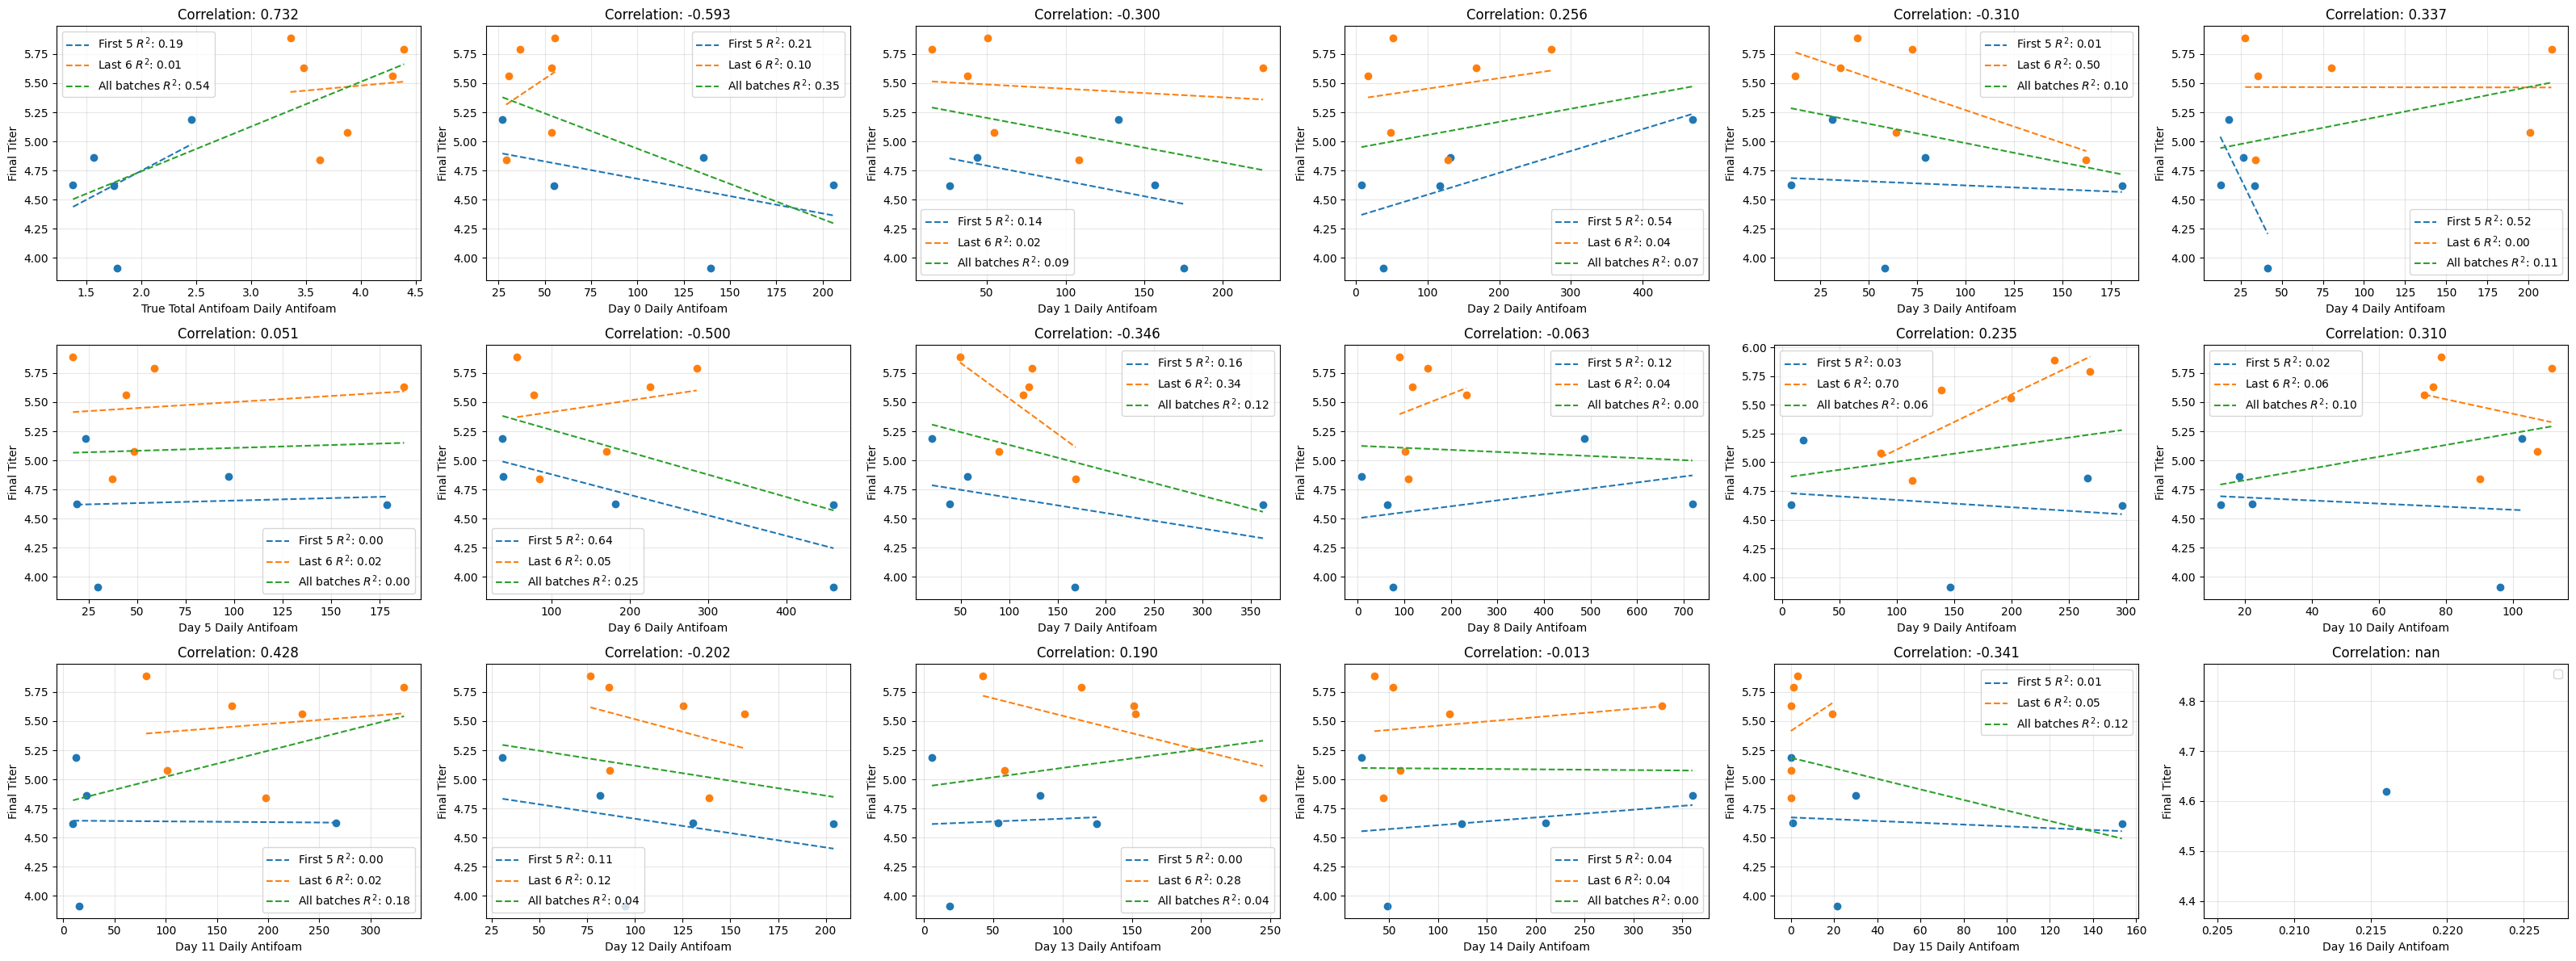

In [22]:
fig, axs = plt.subplots(3, 6, figsize = (32, 12))

for idx in range(18):
    row_idx = idx // 6
    col_idx = idx % 6

    ax = axs[row_idx][col_idx]

    column = antifoam_df.columns[1 + idx]
    ax.scatter(antifoam_df[column][:5], antifoam_df["Last Titer"][:5])

    if idx != 17:
        summary = fit_summary(antifoam_df[column][:5], antifoam_df["Last Titer"][:5])
        ax.plot([summary['x_min'], summary['x_max']], [summary['y_fit_at_x_min'], summary['y_fit_at_x_max']], label = f"First 5 $R^2$: {summary['r2']:.2f}", linestyle = '--')
        ax.scatter(antifoam_df[column][5:], antifoam_df["Last Titer"][5:])
        summary = fit_summary(antifoam_df[column][5:], antifoam_df["Last Titer"][5:])
        ax.plot([summary['x_min'], summary['x_max']], [summary['y_fit_at_x_min'], summary['y_fit_at_x_max']], label = f"Last 6 $R^2$: {summary['r2']:.2f}", linestyle = '--')
        summary = fit_summary(antifoam_df[column], antifoam_df["Last Titer"])
        ax.plot([summary['x_min'], summary['x_max']], [summary['y_fit_at_x_min'], summary['y_fit_at_x_max']], label = f"All batches $R^2$: {summary['r2']:.2f}", linestyle = '--')
        
    corr = np.corrcoef(antifoam_df[column].tolist(), antifoam_df["Last Titer"].tolist())[0, 1]
    ax.set_title(f"Correlation: {corr:.3f}")
    ax.set_xlabel(column + " Daily Antifoam")
    ax.set_ylabel("Final Titer")
    ax.legend()
    ax.grid(alpha = 0.3)
fig.tight_layout()
fig.show()

/tmp/ipykernel_2304150/3472252572.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


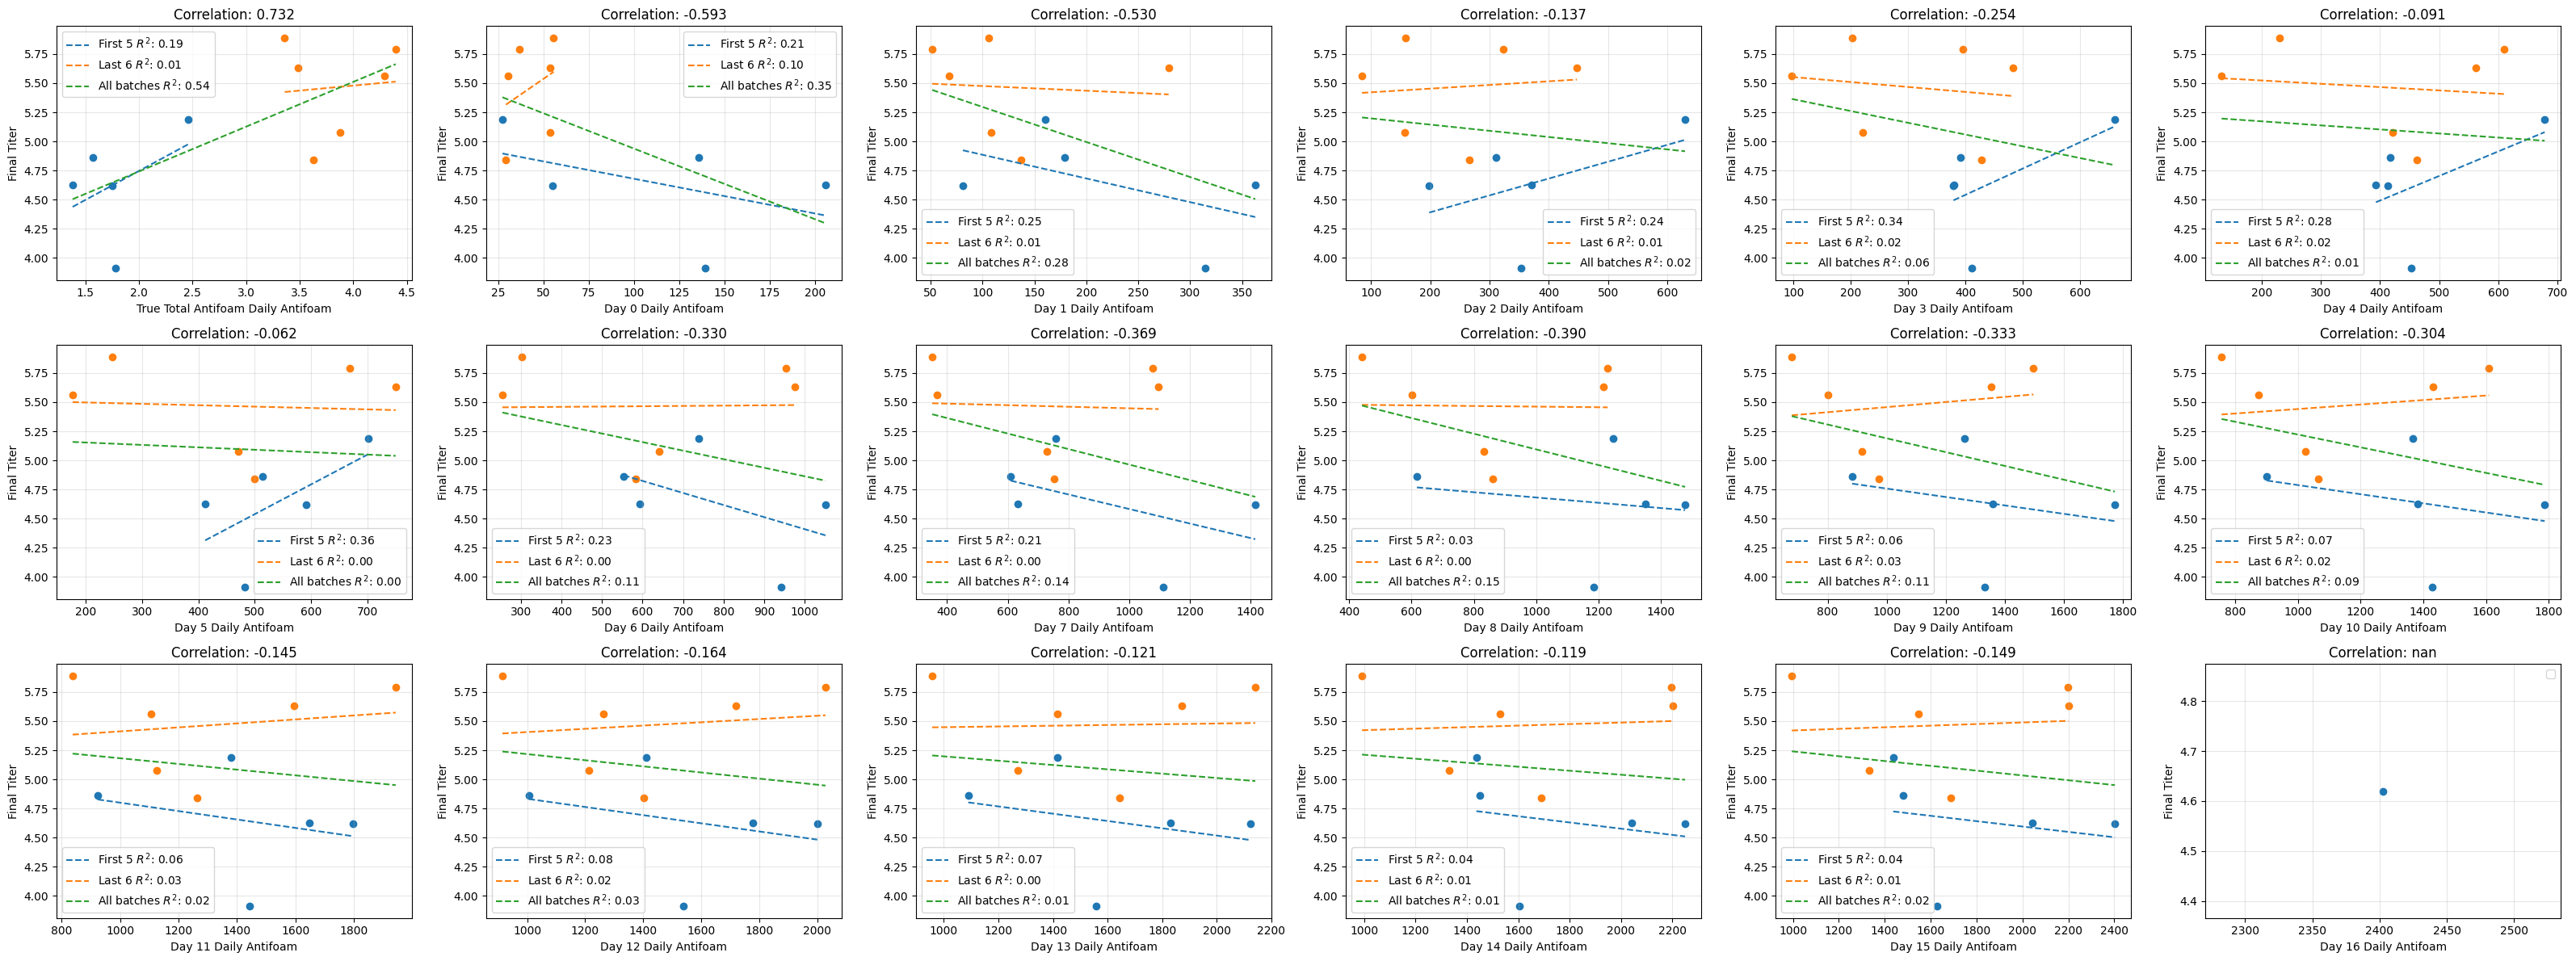

In [32]:
fig, axs = plt.subplots(3, 6, figsize = (32, 12))

for idx in range(18):
    row_idx = idx // 6
    col_idx = idx % 6

    ax = axs[row_idx][col_idx]

    column = antifoam_cum_df.columns[1 + idx]
    ax.scatter(antifoam_cum_df[column][:5], antifoam_cum_df["Last Titer"][:5])

    if idx != 17:
        summary = fit_summary(antifoam_cum_df[column][:5], antifoam_cum_df["Last Titer"][:5])
        ax.plot([summary['x_min'], summary['x_max']], [summary['y_fit_at_x_min'], summary['y_fit_at_x_max']], label = f"First 5 $R^2$: {summary['r2']:.2f}", linestyle = '--')
        ax.scatter(antifoam_cum_df[column][5:], antifoam_cum_df["Last Titer"][5:])
        summary = fit_summary(antifoam_cum_df[column][5:], antifoam_cum_df["Last Titer"][5:])
        ax.plot([summary['x_min'], summary['x_max']], [summary['y_fit_at_x_min'], summary['y_fit_at_x_max']], label = f"Last 6 $R^2$: {summary['r2']:.2f}", linestyle = '--')
        summary = fit_summary(antifoam_cum_df[column], antifoam_cum_df["Last Titer"])
        ax.plot([summary['x_min'], summary['x_max']], [summary['y_fit_at_x_min'], summary['y_fit_at_x_max']], label = f"All batches $R^2$: {summary['r2']:.2f}", linestyle = '--')
        
    corr = np.corrcoef(antifoam_cum_df[column].tolist(), antifoam_cum_df["Last Titer"].tolist())[0, 1]
    ax.set_title(f"Correlation: {corr:.3f}")
    ax.set_xlabel(column + " Daily Antifoam")
    ax.set_ylabel("Final Titer")
    ax.legend()
    ax.grid(alpha = 0.3)
fig.tight_layout()
fig.show()